# Linear Regression with SciKit-Learn


# 1. What is Linear Regression?

- Linear Regression is a **supervised learning algorithm** used to predict a **continuous numeric value**
- Find a mathematical relationship that best explains how features affect the target
- The model tries to fit the **best straight line or hyperplane in multiple dimensions**
- Model learns by choosing coefficients that minimize prediction error.


It models the relationship between:
- Input features
- Target variable

Examples:
- Predict house price
- Predict sales revenue
- Predict salary

Equation: $$
y = b_0 + b_1x_1 + b_2x_2 + ... + b_nx_n
$$

- b_0 = intercept
- b_1, b_2, ... = coefficients of features

## Meaning of Coefficients in Linear Regression

In Linear Regression, each feature has an associated **coefficient** (weight).

## What Does a Coefficient Mean?

coefficient = expected change in the target variable when that feature increases by **1 unit**, while all other features remain constant. The interpretation assumes other variables stay constant and relationship is linear

## Sign of the Coefficient

### Positive Coefficient
Feature increases → target tends to increase

### Negative Coefficient

Feature increases → target tends to decrease

## Magnitude of the Coefficient

Larger absolute value means stronger influence on prediction.


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Advertising Dataset

This dataset contains data about the sales of a product in relation to the advertising budgets spent on TV, radio and newspaper. It's commonly used to explore the relationship between advertising efforts and sales

- Labels: Continuous values representing sales of the product (in thousands of units)
- Size: 200 samples each with 4 attributes

In [4]:
df = pd.read_csv("Advertising.csv")

In [5]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
X = df.drop('sales',axis=1)
y = df['sales']

## Train | Test Split



In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

## Creating a Model (Estimator)

#### Import a model class from a model family

In [9]:
from sklearn.linear_model import LinearRegression

#### Create an instance of the model with parameters

In [10]:
model = LinearRegression()

In [11]:
model.fit(X_train,y_train)

LinearRegression()

In [12]:
model.coef_

array([ 0.04469599,  0.1875657 , -0.00032275])

In [19]:
pd.Series(model.coef_, index=X.columns)

,0
TV,0.044696
radio,0.187566
newspaper,-0.000323


In [13]:
model.intercept_

np.float64(3.1515267680706547)

# Understanding and utilizing the Model

## Evaluation on the Test Set

### Metrics

The three most common evaluation metrics for regression problems:

**Mean Absolute Error** (MAE) is the mean of the absolute value of the errors:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE) is the mean of the squared errors:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) is the square root of the mean of the squared errors:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

Comparing these metrics:

- **MAE** is the average error
- **MSE** punishes" larger errors, which tends to be useful in the real world.
- **RMSE** is even more popular than MSE, because RMSE is interpretable in the "y" units.

All of these are **loss functions**, because we want to minimize them.

### Calculate Performance on Test Set

In [14]:
test_predictions = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [16]:
MAE = mean_absolute_error(y_test,test_predictions)
MSE = mean_squared_error(y_test,test_predictions)
RMSE = np.sqrt(MSE)

In [17]:
print(MAE, MSE, RMSE)

1.213745773614481 2.2987166978863796 1.5161519375993884


## Residual Analysis

$$ Residual =y-\hat{y}
$$

## Interpretation

- Good Sign -> Residuals randomly scattered around zero

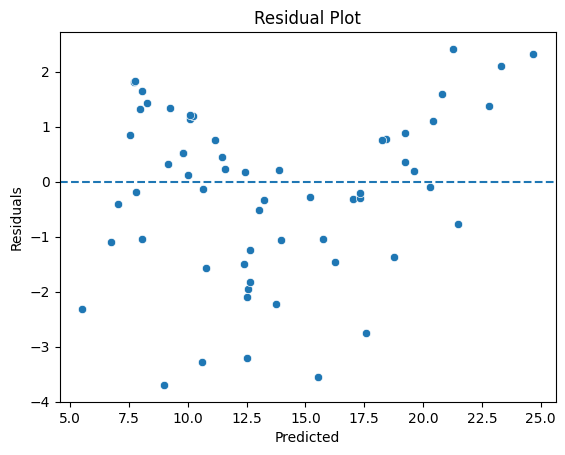

In [18]:
residuals = y_test - test_predictions

sns.scatterplot(x=test_predictions, y=residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### Prediction on New Data

**Our next ad campaign will have a total spend of 149k on TV, 22k on Radio, and 12k on Newspaper Ads, how many units could we expect to sell as a result of this?**

In [20]:
campaign = [[149,22,12]]

In [21]:
model.predict(campaign)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13.93380216])

**How accurate is this prediction? No real way to know! We only know our model's performance on the test data, that is why we had to be satisfied by it first, before training our full model**

# Assumptions of Linear Regression

# 1. Linearity

The relationship between input features and the target should be approximately **linear**
Visualization: scatter plot shows a straight upward or downward trend

# 2. Independence of Observations

Each row in the dataset should represent an observation that is independent from others.

# 3. Homoscedasticity (Constant Variance of Errors)

The spread of prediction errors should remain similar across all predicted values.

# 4. Low Multicollinearity

Input features should not be highly correlated with each other

# 5. Residuals Approximately Normal

Residuals should be roughly normally distributed



# Important Considerations

## 1. Scaling

- Large-scale features may dominate coefficients.

- Use scaling when comparing coefficients or using regularized models.

## 2. Correlated Features

- Highly correlated predictors make coefficients unstable.

- Check using correlation matrix

## 3. Outliers

- Linear regression is sensitive to outliers.

## 4. Non-linear Relationships

If relationship is curved:
- Add polynomial features
- Use tree-based models